# Part 1. An expensive black box

Yesterday you drove SIMION from Python and plotted detector counts against a single voltage. Today the machine has many voltages at once, every measurement is slow, and you cannot try them all. You need a smarter way to decide what to measure next.

In this module you will write, by hand, the kind of optimizer that real beamlines use to tune themselves, and run it against a problem that behaves like the real thing.

We start by meeting the problem.

**How to work.** Read the cells, run them, and stop at the boxes marked *Discuss*. Talk them through with your group before moving on. The four parts build on each other, so do not skip ahead.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for cand in [here, *here.parents]:
    if (cand / "blackbox").is_dir():
        if str(cand) not in sys.path:
            sys.path.insert(0, str(cand))
        break

import numpy as np
import matplotlib.pyplot as plt
from blackbox import plotting
plotting.use_clean_style()

## The machine

We give you a stand-in for an expensive beamline. It is not SIMION and it is not real hardware. It is a function that was built to behave like the real problem in the ways that make the real problem hard:

- you set a vector of normalized voltages, each between -1 and 1,
- it returns two numbers, `Nx` and `Ny`, the counts at the x and y detectors,
- one measurement takes about a minute,
- the counts are noisy, and most settings return almost nothing.

Create it and look at its shape.

In [2]:
from blackbox import VirtualBeamline

beam = VirtualBeamline(seconds_per_eval=60.0, seed=0)
print("number of voltages:", beam.dim)
print("each voltage runs from", beam.lower[0], "to", beam.upper[0])

number of voltages: 12
each voltage runs from -1.0 to 1.0


## The cost of one measurement

Run one real measurement. It takes about a minute by design; on the real beamline it would be closer to twenty. Watch the clock while it runs.

In [3]:
import time

t0 = time.time()
nx, ny = beam.evaluate(np.zeros(beam.dim))
print("counts:", nx, ny)
print("seconds:", round(time.time() - t0, 1))

counts: 0 0
seconds: 60.0


A minute for one reading. If you wanted to try ten settings on each of the twelve voltages, that is `10 ** 12` measurements, which at a minute each is about two million years. Brute force is impossible.

While you write and debug your own code you cannot sit through a minute per call. So the object has a `fast=True` switch that skips the wait. We will use it for everything from here on. The rule we keep is this: **count every evaluation as if it still cost a minute.** The number of measurements is the cost, and the goal is a good answer from as few of them as possible.

> **Note.** `fast=True` only skips the wait, nothing else. The measurement is still noisy, and the noise is *fixed for each setting*: measuring the same voltages again returns the same counts. So you cannot dodge the noise by calling one setting many free times and averaging it away, the way you could on a real detector. Treat the fast switch as a stopwatch trick, not a way around the problem.

In [4]:
beam.reset_counter()

def measure(v):
    nx, ny = beam.evaluate(v, fast=True)
    return nx + ny      # one number to maximize: total counts at both detectors

print("evaluations so far:", beam.n_evals)

evaluations so far: 0


## What does blind search get you?

The simplest honest baseline is to try random settings and keep the best. Spend a budget of 60 measurements this way.

measurements used: 60
best total counts found: 962
fraction of measurements that returned under 10 counts: 0.83


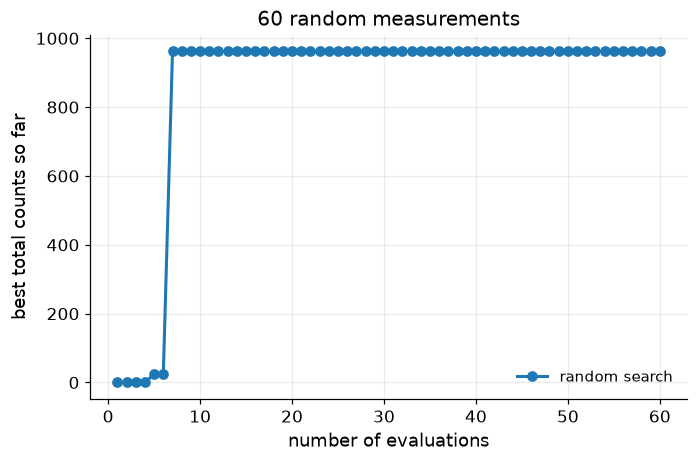

In [5]:
budget = 60
V_random = beam.random_inputs(budget, seed=43)
scores = np.array([measure(v) for v in V_random])
best_so_far = np.maximum.accumulate(scores)

print("measurements used:", beam.n_evals)
print("best total counts found:", int(scores.max()))
print("fraction of measurements that returned under 10 counts:",
      round(np.mean(scores < 10), 2))

ax = plotting.plot_convergence(best_so_far, label="random search")
ax.set_ylabel("best total counts so far")
ax.set_title("60 random measurements")
plt.show()

> **Discuss.** Most of your 60 measurements came back near zero. What does that say about the shape of this space? If a colleague offered to run another 60 random settings overnight, would you expect a much better result? Roughly how many random measurements do you think you would need to be confident you had found a good setting?

The space is mostly empty. The beam only gets through for a narrow set of voltage combinations, and random sampling spends almost all of its budget in the dead region. Adding more random shots helps slowly and expensively.

We can do much better by paying attention. Every measurement, even a zero, tells us something about where the good region is not. If we keep a model of what we have learned and use it to choose the next setting, we can find the good region in a fraction of the measurements.

That model is a Gaussian process, and in the next part you are going to write one from scratch.